# Step 3B — EDA dos slopes ALSFRS-R (3m e 6m)

## 🎯 Objetivo
Analisar a qualidade e o comportamento dos slopes do ALSFRS-R calculados no Step 3A, incluindo:
- **Elegibilidade/coverage** por horizonte (3m, 6m, ambos)
- **Qualidade do slope** (nº de pontos e presença de medição perto de t0+H)
- **Distribuição** dos slopes (histogramas)
- **Consistência intra-doente** entre 3m e 6m (scatter 3m vs 6m)

## 📥 Input
- `01_data/interim/baseline_with_targets_step3_nolabelsv2.csv`  *(1 linha por doente)*

## 📤 Outputs (tabelas/figuras)
- `04_outputs/tables/step3_eligibility_summary.csv`
- `04_outputs/tables/step3_slope_stats.csv`
- `04_outputs/tables/step3_slope_quality_points.csv`
- `04_outputs/figures/step3_hist_slope_3m*.png`
- `04_outputs/figures/step3_hist_slope_6m*.png`
- `04_outputs/figures/step3_scatter_3m_vs_6m*.png`

<div style="padding:10px;border-left:6px solid #FF5F5D;">
<b>Nota:</b> este notebook é descritivo (EDA). A definição binária “rapid” (top 30%) é usada aqui apenas para referência visual; a decisão final do threshold é aplicada no treino (fold-wise).
</div>


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Paths do projeto ===
DATA_INTERIM = os.path.join("..", "01_data", "interim")
OUT_TABLES   = os.path.join("..", "04_outputs", "tables")
OUT_FIGURES  = os.path.join("..", "04_outputs", "figures")

os.makedirs(OUT_TABLES, exist_ok=True)
os.makedirs(OUT_FIGURES, exist_ok=True)

# === Ficheiro Step 3 (baseline + slopes) ===
FILE = os.path.join(DATA_INTERIM, "baseline_with_targets_step3_nolabels.csv")

df = pd.read_csv(FILE)

print("Linhas:", df.shape[0], "| Colunas:", df.shape[1])
df.head()


Linhas: 5436 | Colunas: 28


,subject_id,t0_delta_days,ALSFRS_R_t0,Age,Sex,Ethnicity,Race_Caucasian,Race_Black_African_American,Race_Asian,Race_Americ_Indian_Alaska_Native,...,slope_90d_per_day,slope_90d_per_30d,npoints_90d_window,has_endband_90d,slope_180d_per_day,slope_180d_per_30d,npoints_180d_window,has_endband_180d,pref_ok_90d_min3,pref_ok_180d_min3
0,666,0.0,33.0,42.0,Male,NaN,1.0,NaN,NaN,NaN,...,-0.085472,-2.564168,3,True,-0.050808,-1.524227,4,True,True,True
1,935,0.0,35.0,45.0,Female,Non-Hispanic or Latino,1.0,NaN,NaN,NaN,...,NaN,NaN,4,False,NaN,NaN,7,False,True,True
2,1009,0.0,42.0,51.0,Male,NaN,NaN,1.0,NaN,NaN,...,0.033045,0.991344,4,True,-0.003903,-0.117096,7,True,True,True
3,1036,0.0,47.0,67.0,Female,NaN,NaN,NaN,NaN,NaN,...,-0.022222,-0.666667,2,True,NaN,NaN,2,False,False,False
4,1110,0.0,34.0,NaN,Male,Non-Hispanic or Latino,NaN,NaN,1.0,NaN,...,NaN,NaN,2,False,NaN,NaN,3,False,False,True


## 1) Leitura do dataset intermédio e validação mínima

Nesta secção confirmamos:
- colunas necessárias para EDA (slopes e métricas de qualidade)
- tipos e presença de valores nulos
- consistência básica: 1 linha por doente


In [2]:
needed_cols = [
    "subject_id",
    "slope_90d_per_30d",
    "slope_180d_per_30d",
    "npoints_90d_window",
    "npoints_180d_window",
    "has_endband_90d",
    "has_endband_180d"
]

missing = [c for c in needed_cols if c not in df.columns]
print("Colunas em falta:", missing)

df[needed_cols].describe(include="all")


Colunas em falta: []


,subject_id,slope_90d_per_30d,slope_180d_per_30d,npoints_90d_window,npoints_180d_window,has_endband_90d,has_endband_180d
count,5436.000000,2407.000000,1392.000000,5436.000000,5436.000000,5436,5436
unique,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,NaN,NaN,False,False
freq,NaN,NaN,NaN,NaN,NaN,3029,4044
mean,498134.250552,-0.904053,-0.951320,3.228845,5.091428,NaN,NaN
std,289986.077767,1.162622,0.894979,1.241813,2.141523,NaN,NaN
min,666.000000,-7.785907,-5.227517,1.000000,1.000000,NaN,NaN
25%,247278.500000,-1.500000,-1.412505,2.000000,3.000000,NaN,NaN
50%,491489.000000,-0.681818,-0.795244,4.000000,6.000000,NaN,NaN
75%,751204.500000,-0.103639,-0.322195,4.000000,7.000000,NaN,NaN


## 2) Elegibilidade (coverage): quantos doentes têm slope a 3m, 6m e em ambos?

Um doente é considerado elegível para um horizonte se existir:
- slope calculado para esse horizonte (não nulo)

Reportamos:
- N e % elegíveis para 3m
- N e % elegíveis para 6m
- N e % elegíveis para ambos (útil para análises de consistência)


In [3]:
N = len(df)

ok3  = df["slope_90d_per_30d"].notna()
ok6  = df["slope_180d_per_30d"].notna()
both = ok3 & ok6

summary = pd.DataFrame({
    "horizonte": ["3m (90±7d)", "6m (180±7d)", "Ambos (3m & 6m)"],
    "n_eligiveis": [ok3.sum(), ok6.sum(), both.sum()],
})
summary["pct"] = summary["n_eligiveis"] / N

summary


,horizonte,n_eligiveis,pct
0,3m (90±7d),2407,0.442789
1,6m (180±7d),1392,0.256071
2,Ambos (3m & 6m),720,0.132450


## 2.1) Guardar resumo de elegibilidade

Guardamos esta tabela porque é evidência direta de:
- coverage real do PRO-ACT para os horizontes escolhidos
- tamanho efetivo das amostras para treino e avaliação (Step 5)


In [4]:
out = os.path.join(OUT_TABLES, "step3_eligibility_summary.csv")
summary.to_csv(out, index=False)
print("Guardado:", out)


Guardado: ..\04_outputs\tables\step3_eligibility_summary.csv


## 3) Estatísticas descritivas dos slopes (percentis e dispersão)

Aqui descrevemos o comportamento global do slope (pontos/mês):
- tendência central (mediana)
- dispersão (IQR/percentis)
- extremos (min/max) — úteis para identificar outliers

Isto ajuda a justificar:
- escolha do “top 30%” como região de progressão rápida
- diferenças esperadas entre 3m e 6m (amostra e variabilidade)


In [5]:
def slope_stats(series: pd.Series, name: str) -> pd.DataFrame:
    s = series.dropna()
    return pd.DataFrame([{
        "target": name,
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "p10": s.quantile(0.10),
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "p90": s.quantile(0.90),
        "min": s.min(),
        "max": s.max(),
    }])

stats = pd.concat([
    slope_stats(df["slope_90d_per_30d"],  "slope_3m (pts/30d)"),
    slope_stats(df["slope_180d_per_30d"], "slope_6m (pts/30d)"),
], ignore_index=True)

stats


,target,n,mean,std,p10,p25,p50,p75,p90,min,max
0,slope_3m (pts/30d),2407,-0.904053,1.162622,-2.384069,-1.500000,-0.681818,-0.103639,3.107940e-01,-7.785907,2.164448
1,slope_6m (pts/30d),1392,-0.951320,0.894979,-2.143041,-1.412505,-0.795244,-0.322195,-2.331659e-15,-5.227517,0.847526


## 3.1) Guardar estatísticas descritivas (para reporte na tese)

Esta tabela é “tese-ready” e pode ser usada diretamente na secção de Resultados:
- uma tabela por horizonte
- comparação rápida entre 3m e 6m


In [6]:
out = os.path.join(OUT_TABLES, "step3_slope_stats.csv")
stats.to_csv(out, index=False)
print("Guardado:", out)


Guardado: ..\04_outputs\tables\step3_slope_stats.csv


## 4) Histogramas dos slopes (3m e 6m)

Objetivos dos histogramas:
- visualizar a distribuição do slope (declínio vs estabilidade vs melhoria)
- comparar a forma da distribuição entre 3m e 6m
- destacar referências visuais:
  - linha em 0 (estável)
  - cut-off (top 30% piores slopes) como indicação exploratória

<b>Nota sobre bins:</b> “bins” são os intervalos do eixo X que agrupam os valores do slope.
Mais bins = mais detalhe (mas mais ruído); menos bins = mais suavização (mas menos detalhe).


Escala comum X: -4.714285714285721 a 1.1780157308644141


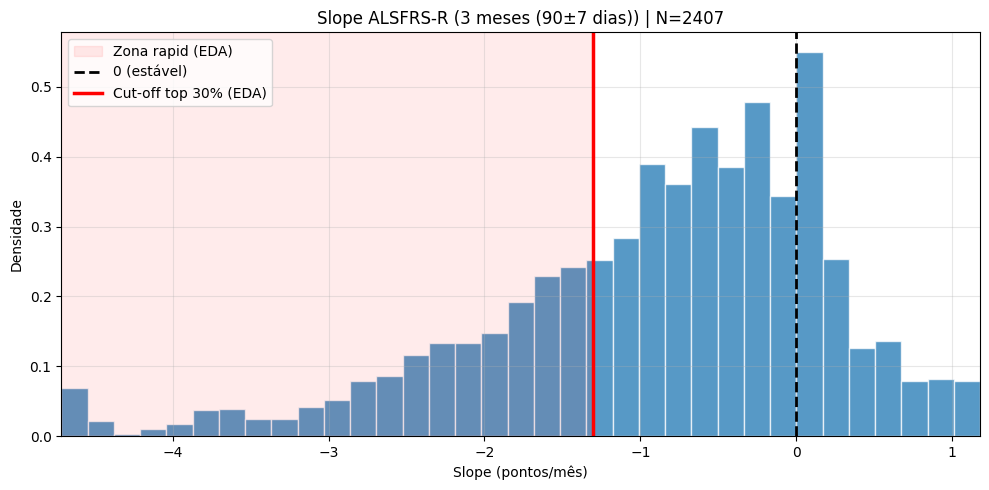

Guardado: ..\04_outputs\figures\step3_hist_slope_3m_commonX.png


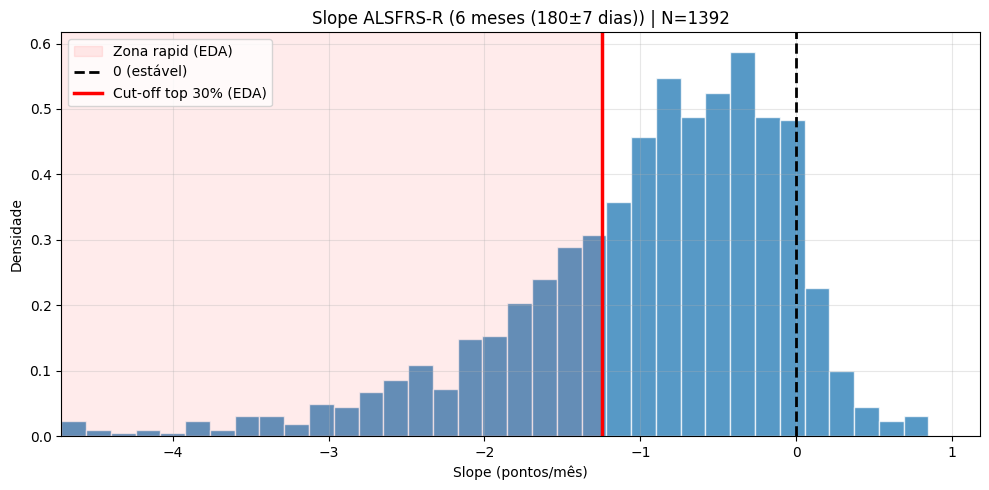

Guardado: ..\04_outputs\figures\step3_hist_slope_6m_commonX.png


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- 1) calcular escala comum (1% a 99% em ambos os horizontes) ---
s3 = df["slope_90d_per_30d"].dropna()
s6 = df["slope_180d_per_30d"].dropna()

x_min_common = float(min(s3.quantile(0.01), s6.quantile(0.01)))
x_max_common = float(max(s3.quantile(0.99), s6.quantile(0.99)))

print("Escala comum X:", x_min_common, "a", x_max_common)

# --- 2) função de plot com limites fixos ---
def plot_hist_slope_common(df, col, horizon_label, outname, bins=35, shade_rapid=True,
                           x_min=None, x_max=None):
    s = df[col].dropna()

    # clip para manter a mesma escala e evitar que outliers distorçam
    s_plot = s.clip(x_min, x_max)

    cutoff = float(s.quantile(0.30))  # EDA: 30% mais negativos

    plt.figure(figsize=(10, 5))

    plt.hist(
        s_plot,
        bins=bins,
        density=True,
        edgecolor="white",
        linewidth=1.0,
        alpha=0.75
    )

    if shade_rapid:
        plt.axvspan(x_min, min(cutoff, x_max), color="red", alpha=0.08, label="Zona rapid (EDA)")

    plt.axvline(0, color="black", linewidth=2, linestyle="--", label="0 (estável)")
    plt.axvline(cutoff, color="red", linewidth=2.5, linestyle="-", label="Cut-off top 30% (EDA)")

    plt.title(f"Slope ALSFRS-R ({horizon_label}) | N={len(s)}")
    plt.xlabel("Slope (pontos/mês)")
    plt.ylabel("Densidade")

    plt.xlim(x_min, x_max)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out = os.path.join(OUT_FIGURES, outname)
    plt.savefig(out, dpi=300)
    plt.show()
    print("Guardado:", out)

# --- 3) gerar os 2 histogramas com a mesma escala ---
plot_hist_slope_common(
    df, "slope_90d_per_30d",
    "3 meses (90±7 dias)",
    "step3_hist_slope_3m_commonX.png",
    bins=35, shade_rapid=True,
    x_min=x_min_common, x_max=x_max_common
)

plot_hist_slope_common(
    df, "slope_180d_per_30d",
    "6 meses (180±7 dias)",
    "step3_hist_slope_6m_commonX.png",
    bins=35, shade_rapid=True,
    x_min=x_min_common, x_max=x_max_common
)


## 5) Consistência 3m vs 6m (doentes com ambos os slopes)

O scatter (3m vs 6m) serve para perceber:
- se quem declina cedo também tende a declinar mais tarde
- se há casos “mistos” (ex.: piora aos 3m mas estabiliza aos 6m, ou vice-versa)

Interpretação rápida por quadrantes:
- x<0 e y<0: declínio em ambos os horizontes
- x>0 e y>0: melhoria em ambos (menos frequente)
- mistos: padrões não monotónicos / variabilidade / ruído de medição


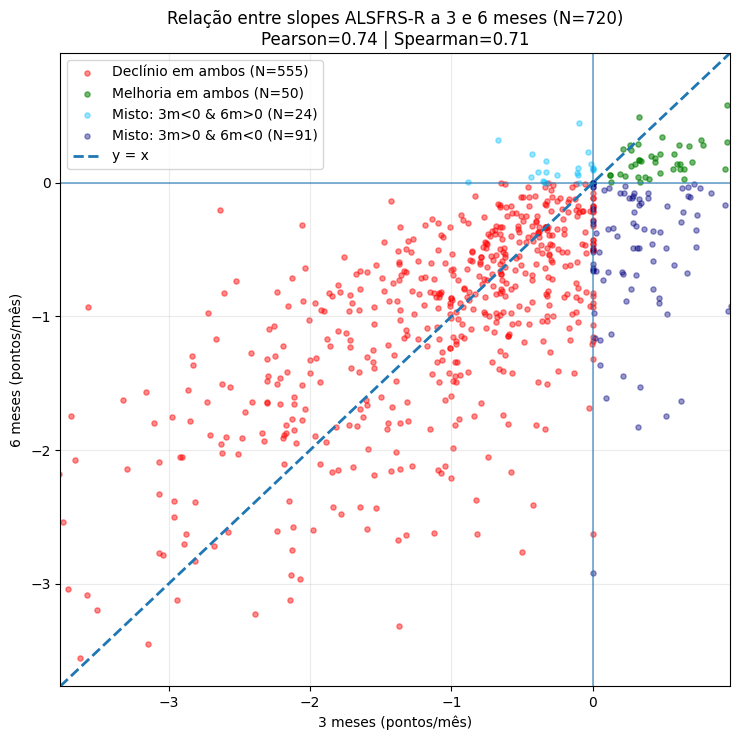

Guardado: ..\04_outputs\figures\step3_scatter_3m_vs_6m_quadrants_v2.png


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# assumes you already have:
# df, OUT_FIGURES

both = df["slope_90d_per_30d"].notna() & df["slope_180d_per_30d"].notna()
x = df.loc[both, "slope_90d_per_30d"].to_numpy()
y = df.loc[both, "slope_180d_per_30d"].to_numpy()

# --- correlações (quantificar o que o olho vê) ---
rp = pearsonr(x, y)[0]
rs = spearmanr(x, y)[0]

# --- máscaras por quadrantes / grupos ---
decline_both = (x < 0) & (y < 0)
improve_both = (x > 0) & (y > 0)

# mistos em 2 subgrupos (direção)
mixed_3m_decline_6m_improve = (x < 0) & (y > 0)   # melhora aos 6m
mixed_3m_improve_6m_decline = (x > 0) & (y < 0)   # piora aos 6m

# casos exatamente em 0 (ou colados a 0) — mantemos como "misto"
mixed_zero = ~(decline_both | improve_both |
               mixed_3m_decline_6m_improve | mixed_3m_improve_6m_decline)

# --- limites iguais (1% a 99%) para não achatar por outliers ---
lim_lo, lim_hi = np.quantile(np.concatenate([x, y]), [0.01, 0.99])
lim_lo, lim_hi = float(lim_lo), float(lim_hi)

plt.figure(figsize=(7.5, 7.5))

# pontos (cores por grupo)
plt.scatter(x[decline_both], y[decline_both],
            s=14, alpha=0.45, color="red",
            label=f"Declínio em ambos (N={decline_both.sum()})")

plt.scatter(x[improve_both], y[improve_both],
            s=14, alpha=0.55, color="green",
            label=f"Melhoria em ambos (N={improve_both.sum()})")

plt.scatter(x[mixed_3m_decline_6m_improve], y[mixed_3m_decline_6m_improve],
            s=14, alpha=0.40, color="deepskyblue",
            label=f"Misto: 3m<0 & 6m>0 (N={mixed_3m_decline_6m_improve.sum()})")

plt.scatter(x[mixed_3m_improve_6m_decline], y[mixed_3m_improve_6m_decline],
            s=14, alpha=0.40, color="navy",
            label=f"Misto: 3m>0 & 6m<0 (N={mixed_3m_improve_6m_decline.sum()})")

if mixed_zero.any():
    plt.scatter(x[mixed_zero], y[mixed_zero],
                s=14, alpha=0.35, color="gray",
                label=f"Zeros/limite (N={mixed_zero.sum()})")

# linhas de referência (mais leves)
plt.axhline(0, linewidth=1.2, alpha=0.65)
plt.axvline(0, linewidth=1.2, alpha=0.65)

# linha y=x (consistência perfeita)
plt.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
         linestyle="--", linewidth=2, label="y = x")

# título mais sóbrio + correlação
plt.title(f"Relação entre slopes ALSFRS-R a 3 e 6 meses (N={len(x)})\n"
          f"Pearson={rp:.2f} | Spearman={rs:.2f}")
plt.xlabel("3 meses (pontos/mês)")
plt.ylabel("6 meses (pontos/mês)")

plt.xlim(lim_lo, lim_hi)
plt.ylim(lim_lo, lim_hi)

plt.grid(True, alpha=0.25)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()

out = os.path.join(OUT_FIGURES, "step3_scatter_3m_vs_6m_quadrants_v2.png")
plt.savefig(out, dpi=300)
plt.show()

print("Guardado:", out)


## 4) Qualidade do slope (robustez do cálculo)

Antes de usar os slopes como base para definir “rapid vs slow”, validamos a qualidade do cálculo.  
O objetivo aqui não é “melhorar” os slopes, é **caracterizar** a sua robustez.

### O que verificamos
- **Nº de pontos usados no ajuste** (ex.: 2, 3, 4+ medições)
- **Janela temporal efetiva** (quantos dias entre a primeira e a última medição usada)
- **Presença de medição perto do alvo** (se existe um ponto próximo de t0+H dentro de ±7 dias)

### Porque isto importa
- Com **2 pontos**, o slope é basicamente uma diferença entre baseline e follow-up (mais sensível a ruído).
- Com **3+ pontos**, o ajuste por regressão linear tende a ser mais estável.
- Se não existir medição perto do t0+H, o slope pode ficar menos representativo do horizonte (mesmo que matematicamente “exista”).

Esta secção serve para justificar, na tese, que os targets foram construídos com controlo mínimo de qualidade e que as limitações (coverage/medições) são conhecidas e reportadas.


In [9]:
qual = pd.DataFrame({
    "horizonte": ["3m", "6m"],
    "pct_npoints_ge3": [
        (df.loc[ok3, "npoints_90d_window"] >= 3).mean(),
        (df.loc[ok6, "npoints_180d_window"] >= 3).mean(),
    ],
    "median_npoints": [
        df.loc[ok3, "npoints_90d_window"].median(),
        df.loc[ok6, "npoints_180d_window"].median(),
    ]
})

qual


,horizonte,pct_npoints_ge3,median_npoints
0,3m,0.904861,4.0
1,6m,0.997845,7.0


## 4.1) Guardar resumo de qualidade do slope

Guardamos um resumo “tese-ready” com a qualidade dos slopes por horizonte, incluindo:
- contagens por nº de pontos (ex.: 2 vs ≥3)
- percentagens (para comparar 3m vs 6m)
- (opcional) estatísticas do span temporal

Isto é útil para:
- justificar escolhas metodológicas
- explicar diferenças entre horizontes (ex.: 6m ter menos doentes e por vezes menos medições)
- suportar a secção de limitações/Threats to Validity


In [10]:
out = os.path.join(OUT_TABLES, "step3_slope_quality_npoints.csv")
qual.to_csv(out, index=False)
print("Guardado:", out)


Guardado: ..\04_outputs\tables\step3_slope_quality_npoints.csv
